# D009 — 데이터 품질 진단 및 EDA 보고서
## KBO 팬 멤버십 데이터

**사용 데이터**: 외부 데이터 (선택 2) — KBO 팬 멤버십/구매 실습용 샘플 데이터
**데이터 위치**: `data/kbo_fan_data_sample.csv`
**출처 노트**: `data/source_note.md` 참고 (공개 URL 없는 커리큘럼 제공 실습 데이터, email 컬럼은 개인정보 보호를 위해 사전 제거)

> 표(데이터프레임 출력, 마크다운 표)에 들어가는 컬럼명·값·요약 문구는 영문으로 통일했습니다.
> 한글 폰트가 없는 환경에서 표가 깨지는 문제를 피하기 위한 조치이며, 설명 텍스트는 한글 그대로입니다.

---

### 진행 흐름
```
데이터 선택 → 데이터 개요 파악 → 품질 진단 → 정제 → 정제 전후 비교
→ EDA → 한계와 후속 질문
```


In [1]:
# ============================================================
# 0. 환경 준비
#    - 필요한 라이브러리를 불러오고, 표/차트 출력 옵션을 설정합니다.
# ============================================================
import pandas as pd            # 표 형태 데이터(DataFrame)를 다루는 핵심 라이브러리
import numpy as np             # 결측치(NaN) 표시, 수치 계산에 사용
import re                      # 정규식 — 날짜/문자열 표기 패턴을 구분할 때 사용
import matplotlib.pyplot as plt        # 차트(히스토그램, 막대그래프 등) 그리기
import matplotlib.font_manager as fm   # 차트에 한글 폰트를 등록하기 위해 사용
import os                      # 폴더 생성, 파일 크기 확인 등 파일 시스템 작업

# 데이터프레임을 출력할 때 컬럼이 잘리지 않고 다 보이도록 설정
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# 한글 폰트 등록
# -> matplotlib은 기본적으로 한글 폰트를 갖고 있지 않아서, 그냥 차트에 한글을 쓰면
#    글자가 네모 박스(□)로 깨져 보입니다.
# -> 이 문제를 피하려고 나눔고딕 폰트 파일(fonts/NanumGothic-Regular.ttf)을
#    리포지토리에 함께 넣어두고, 아래에서 그 폰트를 matplotlib에 직접 등록합니다.
# -> 이렇게 하면 이 노트북을 어떤 컴퓨터에서 열어도(로컬/서버/동료 PC) 한글 차트가 깨지지 않습니다.
FONT_PATH = "fonts/NanumGothic-Regular.ttf"
if os.path.exists(FONT_PATH):
    fm.fontManager.addfont(FONT_PATH)
    plt.rcParams["font.family"] = fm.FontProperties(fname=FONT_PATH).get_name()
plt.rcParams["axes.unicode_minus"] = False  # 마이너스(-) 기호가 깨지는 것도 함께 방지

# 데이터 경로와 결과 저장 폴더를 변수로 미리 정의해둡니다.
# (경로를 코드 여기저기에 직접 쓰지 않고 변수로 관리하면, 나중에 경로가 바뀌어도 한 곳만 고치면 됩니다.)
DATA_PATH = "data/kbo_fan_data_sample.csv"
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)  # outputs 폴더가 없으면 새로 생성 (있으면 그냥 통과)

## 1. 데이터 개요

- **출처**: 커리큘럼 실습용 합성 데이터 (Kaggle/공공데이터포털 데이터 아님, 자세한 내용은 `data/source_note.md`)
- **관측 단위**: 한 행 = 한 명의 KBO 팬(멤버십 가입 고객)
- **분석 질문**: *구단·지역·멤버십 등급에 따라 팬들의 지출·관람 패턴에 차이가 있는가?*

| Column | Description |
|---|---|
| customer_id | Synthetic fan ID |
| age | Age |
| region | Region of residence |
| favorite_team | Favorite KBO team |
| join_date | Membership join date |
| membership_tier | Membership tier (Bronze/Silver/Gold/VIP) |
| season_ticket_yn | Season ticket holder flag |
| purchase_count | Number of purchases |
| total_spent | Total amount spent |
| last_purchase_date | Most recent purchase date |
| sns_follow_yn | SNS follow flag |
| referral_source | Sign-up channel |
| attended_games | Number of games attended |
| favorite_seat_section | Preferred seat section |

**특히 중요하게 볼 컬럼**: `favorite_team`, `membership_tier`, `region` (범주별 비교 기준) / `total_spent`, `attended_games`, `purchase_count` (핵심 수치 지표)


In [2]:
# CSV 파일을 읽어와 raw(원본) 데이터프레임을 만듭니다.
# -> 이 시점에서는 아직 아무것도 정제하지 않은 "날것" 상태로 둡니다.
#    문제를 있는 그대로 확인해야 다음 Part에서 정확히 진단할 수 있기 때문입니다.
raw = pd.read_csv(DATA_PATH)

print("shape:", raw.shape)   # (행 수, 열 수) 확인
print()
print(raw.dtypes)            # 각 컬럼이 어떤 자료형으로 읽혔는지 확인 (예: 날짜가 문자열로 읽혔는지 등)
raw.head()                    # 위에서 5개 행만 미리보기

shape: (5075, 14)

customer_id                  str
age                      float64
region                       str
favorite_team                str
join_date                    str
membership_tier              str
season_ticket_yn             str
purchase_count           float64
total_spent              float64
last_purchase_date           str
sns_follow_yn            float64
referral_source              str
attended_games             int64
favorite_seat_section        str
dtype: object


,customer_id,age,region,favorite_team,join_date,membership_tier,season_ticket_yn,purchase_count,total_spent,last_purchase_date,sns_follow_yn,referral_source,attended_games,favorite_seat_section
0,KBOFAN0002254,42.0,Seoul City,doosan bears,12/31/2018,NaN,1,5.0,213732.0,2025-03-08,1.0,SNS,13,Outfield
1,KBOFAN0000173,62.0,Seoul,Doosan Bears,2022-12-06,Bronze,0,5.0,155392.0,2025.08.07,NaN,Advertisement,11,Infield
2,KBOFAN0001339,16.0,Busan City,SSGLanders,2022-03-16,Bronze,Y,7.0,355804.0,2024.10.22,0.0,Offline Event,11,Family Zone
3,KBOFAN0003440,61.0,Incheon-si,DoosanBears,2020-04-16,VIP,N,5.0,306801.0,2025-10-13,1.0,Club Website,6,Premium Box
4,KBOFAN0000214,32.0,SEOUL,KIA Tigers,09/08/2017,Silver,Yes,5.0,200056.0,2025-03-24,1.0,Advertisement,7,Outfield


## 2. 데이터 품질 진단

`quality_report_full()` 함수로 구조·결측·중복·타입·이상치를 한 번에 진단합니다. (아래 결과 표는 영문으로 출력됩니다.)

In [3]:
# ============================================================
# quality_report_full() — 데이터 품질을 한 번에 진단하는 함수
#   병원 건강검진표처럼, 어떤 데이터가 들어와도 항상 같은 항목·같은 형식으로
#   결측치·중복·이상치·자료형 문제를 점검합니다.
# ============================================================
def quality_report_full(df: pd.DataFrame, missing_threshold: float = 30.0) -> pd.DataFrame:
    """구조·결측·중복·타입·이상치를 한 표로 진단한다. (표 컬럼/값은 영문 통일)"""
    rows = []               # 컬럼별 진단 결과를 하나씩 담아둘 리스트
    n = len(df)              # 전체 행 수 (결측률 등을 계산할 때 분모로 사용)

    for col in df.columns:                    # 모든 컬럼을 하나씩 순회하며 검사
        s = df[col]
        dtype = str(s.dtype)                  # 현재 자료형 (object, int64, float64 등)
        n_missing = s.isna().sum()            # 결측치(NaN) 개수
        missing_pct = round(n_missing / n * 100, 2)   # 결측 비율(%)

        # --- ① 날짜인데 문자열(object)로 읽힌 컬럼인지 의심해보기 ---
        # object 타입 컬럼의 값 일부를 날짜로 변환해보고, 80% 이상 성공하면
        # "이 컬럼은 사실 날짜다"라고 표시합니다.
        maybe_datetime = False
        if s.dtype == object:
            sample = s.dropna().astype(str).head(50)   # 계산 속도를 위해 50개만 샘플링
            try:
                parsed = pd.to_datetime(sample, errors="coerce", format="mixed")
                maybe_datetime = parsed.notna().mean() > 0.8
            except Exception:
                maybe_datetime = False

        # --- ② 수치형 컬럼이면 IQR(사분위범위) 방식으로 이상치 비율 계산 ---
        # Q1(25% 지점)과 Q3(75% 지점) 사이 거리(IQR)의 1.5배를 벗어나는 값을 이상치로 봅니다.
        outlier_pct = np.nan
        if pd.api.types.is_numeric_dtype(s):
            q1, q3 = s.quantile(0.25), s.quantile(0.75)
            iqr = q3 - q1
            lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            outlier_pct = round(((s < lo) | (s > hi)).mean() * 100, 2)

        # 이 컬럼의 진단 결과를 한 줄(딕셔너리)로 정리해서 rows에 추가
        rows.append({
            "column": col,
            "dtype": dtype,
            "n_missing": n_missing,
            "missing_pct": missing_pct,
            # 결측률이 임계값(기본 30%)을 넘으면 경고 표시를 붙입니다.
            "flag_high_missing": "WARN" if missing_pct >= missing_threshold else "",
            "n_unique": s.nunique(dropna=True),   # 고유값 개수 (표기 혼재를 의심할 실마리)
            "maybe_datetime": maybe_datetime,
            "outlier_pct_iqr": outlier_pct,
        })

    report = pd.DataFrame(rows)

    # 컬럼별 정보 말고, 데이터셋 전체에 대한 정보는 .attrs에 별도로 저장해둡니다.
    # (attrs는 데이터프레임에 붙일 수 있는 "메타정보 보관함" 같은 개념입니다.)
    report.attrs["n_rows"] = n
    report.attrs["n_cols"] = df.shape[1]
    report.attrs["n_duplicates_full"] = df.duplicated().sum()   # 완전히 똑같은 행 개수
    report.attrs["n_duplicates_by_customer_id"] = (
        # customer_id 기준으로 중복인 행 개수
        # (완전 중복보다 이 숫자가 크면, "같은 사람인데 값이 다른" 스냅샷 충돌이 있다는 뜻)
        df.duplicated(subset=["customer_id"]).sum() if "customer_id" in df.columns else None
    )
    return report


# 원본 데이터에 진단 함수를 실행합니다.
q_report = quality_report_full(raw)

print("전체 행 수:", q_report.attrs["n_rows"], "| 전체 열 수:", q_report.attrs["n_cols"])
print("완전 중복 행 수:", q_report.attrs["n_duplicates_full"])
print("customer_id 기준 중복 행 수:", q_report.attrs["n_duplicates_by_customer_id"])
q_report

전체 행 수: 5075 | 전체 열 수: 14
완전 중복 행 수: 50
customer_id 기준 중복 행 수: 75


,column,dtype,n_missing,missing_pct,flag_high_missing,n_unique,maybe_datetime,outlier_pct_iqr
0,customer_id,str,0,0.00,,5000,False,NaN
1,age,float64,150,2.96,,64,False,0.14
2,region,str,204,4.02,,70,False,NaN
3,favorite_team,str,101,1.99,,50,False,NaN
4,join_date,str,0,0.00,,4157,False,NaN
5,membership_tier,str,255,5.02,,4,False,NaN
6,season_ticket_yn,str,0,0.00,,8,False,NaN
7,purchase_count,float64,99,1.95,,19,False,0.06
8,total_spent,float64,0,0.00,,4960,False,2.33
9,last_purchase_date,str,0,0.00,,2851,False,NaN


**진단 결과 해석**

- 결측률이 가장 높은 컬럼은 `sns_follow_yn`(약 10%), 그 뒤로 `membership_tier`(5%), `region`/`favorite_seat_section`(4%대)이 이어집니다.
- 완전 중복 행 50건 + `customer_id` 기준 중복 75건 — 즉 25건은 **같은 사람인데 값이 다른** 스냅샷 충돌입니다.
- `age`, `purchase_count`, `total_spent`, `attended_games`에서 IQR 기준 이상치가 관찰됩니다 (특히 `total_spent`가 2%대로 가장 높음).
- `join_date`/`last_purchase_date`는 표기가 4종류로 섞여 있어 `maybe_datetime`이 정확히 안 잡힐 수 있으므로, 아래에서 직접 표기 패턴을 확인합니다.


In [4]:
# 위 진단표는 "결측률·이상치 비율" 같은 숫자 요약이라, 실제로 어떤 값들이
# 섞여 있는지는 직접 눈으로 한 번 더 확인하는 게 안전합니다.

# region 컬럼에 몇 가지 다른 표기가 섞여 있는지 확인
# (공백/대소문자를 무시하고 봐도 몇 종류인지 함께 보기 위해 strip().lower() 적용)
print("region 표기 종류 수:", raw["region"].dropna().nunique())
print(raw["region"].dropna().str.strip().str.lower().value_counts().head(6))
print()

# favorite_team도 마찬가지로 몇 종류인지 확인
print("favorite_team 표기 종류 수:", raw["favorite_team"].dropna().nunique())
print()

# season_ticket_yn 값 종류를 그대로 확인 (Y/N을 몇 가지 방식으로 적었는지)
print("season_ticket_yn 표기:", raw["season_ticket_yn"].value_counts(dropna=False).to_dict())
print()

# 날짜 컬럼 샘플을 몇 개 뽑아서 실제로 어떤 포맷들이 섞여 있는지 눈으로 확인
print("join_date 표기 샘플:", raw["join_date"].sample(6, random_state=1).tolist())

region 표기 종류 수: 70
region
daegu       387
cheongju    365
busan       357
daejeon     347
incheon     344
jeju        340
Name: count, dtype: int64



favorite_team 표기 종류 수: 50

season_ticket_yn 표기: {'n': 674, '1': 637, 'No': 636, 'y': 636, 'N': 633, 'Yes': 631, '0': 623, 'Y': 605}

join_date 표기 샘플: ['2022.12.30', '2022-03-21', '2016-07-16', '2018.08.11', '12-01-2018', '10/23/2016']


## 3. 정제 과정과 판단 근거

중복 → 문자열 → 날짜 → 이상치 → 결측치 순서로 정제합니다. 각 단계를 함수로 분리하고 `.pipe()`로 연결합니다.
(아래 결정 로그 표의 내용은 영문으로 기록합니다.)

> 💡 정제 순서가 중요한 이유: 문자열이 정리되기 전에 날짜를 파싱하면 표기가 섞인 채로 실패하고,
> 이상치를 먼저 판단하면 아직 정리되지 않은 값 때문에 판단이 왜곡될 수 있습니다.


In [5]:
# 각 정제 단계에서 내린 결정과 그 이유를 순서대로 쌓아둘 리스트입니다.
# 나중에 이 리스트를 표(DataFrame)로 바꿔서 "정제 결정 로그"로 보여줍니다.
DECISION_LOG = []

def log_decision(step, reason, result):
    """정제 단계 하나가 끝날 때마다, 무엇을(step) 왜(reason) 했고 결과가 어땠는지(result)를 기록합니다."""
    DECISION_LOG.append({"step": step, "rationale": reason, "result": result})

In [6]:
# ------------------------------------------------------------
# 1단계: 중복 행 처리
# ------------------------------------------------------------
def drop_duplicates_step(df: pd.DataFrame) -> pd.DataFrame:
    before = len(df)
    full_dup = df.duplicated().sum()   # 모든 컬럼 값이 완전히 똑같은 행 개수

    # 완전 중복 행은 같은 데이터가 실수로 두 번 들어온 것이므로 바로 제거합니다.
    df = df.drop_duplicates()

    # 완전 중복은 아니지만 customer_id가 같은 행이 남아있다면,
    # "같은 고객의 서로 다른 시점 기록(스냅샷)"일 가능성이 높습니다.
    # -> 어떤 스냅샷이 최신인지 판단하기 위해, last_purchase_date를 임시로 날짜로 변환합니다.
    df["_last_purchase_tmp"] = pd.to_datetime(df["last_purchase_date"].apply(_parse_date), errors="coerce")

    # customer_id 기준으로 정렬 후 가장 마지막(=가장 최근 구매일) 행만 남기고 나머지는 버립니다.
    # keep="last" 이므로, 먼저 오름차순 정렬해서 가장 최근 날짜가 맨 마지막에 오게 만든 뒤 남깁니다.
    df = (df.sort_values("_last_purchase_tmp")
            .drop_duplicates(subset=["customer_id"], keep="last")
            .drop(columns="_last_purchase_tmp"))   # 임시로 만든 컬럼은 다시 삭제

    after = len(df)
    log_decision(
        "1. Duplicate handling",
        f"Removed {full_dup} fully duplicated rows first. The remaining {before - full_dup - after} rows "
        f"sharing a customer_id were treated as snapshots of the same fan at different points in time, "
        f"keeping only the row with the most recent last_purchase_date.",
        f"{before} rows -> {after} rows",
    )
    return df.reset_index(drop=True)   # 행을 지운 뒤에는 인덱스를 0부터 다시 매겨줍니다.

In [7]:
# ------------------------------------------------------------
# 2단계: 문자열 정제 (표기 통일)
# ------------------------------------------------------------

# region 끝에 붙은 '-si' 또는 'city' 같은 접미사를 찾아내는 정규식
# (대소문자 상관없이 찾도록 IGNORECASE 옵션을 줍니다)
_REGION_SUFFIX = re.compile(r"(-si|\s*city)$", flags=re.IGNORECASE)

def clean_strings_step(df: pd.DataFrame) -> pd.DataFrame:
    before_region = df["region"].dropna().nunique()
    before_team = df["favorite_team"].dropna().nunique()

    # region 정제: 앞뒤 공백 제거 -> 전부 소문자로 -> '-si'/'city' 접미사 제거 -> 다시 보기 좋게 Title Case로
    # 예) "Seoul City", " seoul-si ", "SEOUL" -> 모두 "Seoul" 하나로 합쳐집니다.
    df["region"] = (
        df["region"].astype("string")
        .str.strip()
        .str.lower()
        .str.replace(_REGION_SUFFIX, "", regex=True)
        .str.strip()
        .str.title()
    )

    # favorite_team 정제: 공백을 전부 없애고 소문자로 바꾼 뒤("doosanbears"),
    # 표준 구단명 딕셔너리에 매핑합니다. 이렇게 하면 띄어쓰기·대소문자가 달라도 같은 값으로 모입니다.
    team_key = df["favorite_team"].astype("string").str.replace(r"\s+", "", regex=True).str.lower()
    team_canonical = {
        "doosanbears": "Doosan Bears", "lgtwins": "LG Twins", "kiatigers": "KIA Tigers",
        "samsunglions": "Samsung Lions", "ssglanders": "SSG Landers", "lottegiants": "Lotte Giants",
        "kiwoomheroes": "Kiwoom Heroes", "ncdinos": "NC Dinos", "hanwhaeagles": "Hanwha Eagles",
        "ktwiz": "KT Wiz",
    }
    df["favorite_team"] = team_key.map(team_canonical)

    # season_ticket_yn 정제: y/yes/1/Y/... 8가지 표기를 하나의 매핑 딕셔너리로 0 또는 1로 통일
    yn_map = {"y": 1, "yes": 1, "1": 1, 1: 1, "n": 0, "no": 0, "0": 0, 0: 0}
    df["season_ticket_yn"] = df["season_ticket_yn"].astype(str).str.strip().str.lower().map(yn_map)

    after_region = df["region"].dropna().nunique()
    after_team = df["favorite_team"].dropna().nunique()
    log_decision(
        "2. String cleaning & label standardization",
        "region mixed case, whitespace, and '-si'/'city' suffixes, splitting the same region into many "
        "distinct labels. favorite_team mixed whitespace, case, and spacing. season_ticket_yn used 8 "
        "different spellings for Yes/No, standardized to 0/1.",
        f"region {before_region} labels -> {after_region} labels, "
        f"favorite_team {before_team} labels -> {after_team} labels, "
        f"season_ticket_yn 8 labels -> 2 (0/1)",
    )
    return df

In [8]:
# ------------------------------------------------------------
# 3단계: 날짜 파싱
# ------------------------------------------------------------
def _parse_date(s):
    """
    4종 날짜 포맷을 표기 패턴별로 구분해 명시적으로 파싱하는 함수.

    왜 이렇게 복잡하게 하나씩 구분해서 처리할까?
    -> '/' 포맷(MM/DD/YYYY)은 "월-일-년" 순서이고, '-' 포맷(DD-MM-YYYY)은 "일-월-년" 순서로
       서로 정반대입니다. pd.to_datetime(format='mixed')로 한꺼번에 자동 인식시키면
       이 둘을 구분하지 못하고 조용히 월과 일을 뒤바꿔 파싱할 위험이 있습니다.
       그래서 정규식으로 먼저 "이 문자열이 어떤 포맷인지"를 확인한 다음,
       포맷에 맞는 정확한 규칙으로 변환합니다.
    """
    if pd.isna(s):
        return pd.NaT   # 원래 결측이었던 값은 그대로 결측(NaT, Not a Time)으로 둡니다.

    s = str(s)
    if re.match(r"^\d{4}-\d{2}-\d{2}$", s):          # 예: 2020-05-01
        return pd.to_datetime(s, format="%Y-%m-%d", errors="coerce")
    if re.match(r"^\d{4}\.\d{2}\.\d{2}$", s):        # 예: 2020.05.01
        return pd.to_datetime(s, format="%Y.%m.%d", errors="coerce")
    if re.match(r"^\d{2}/\d{2}/\d{4}$", s):          # 예: 05/01/2020 (월/일/년)
        return pd.to_datetime(s, format="%m/%d/%Y", errors="coerce")
    if re.match(r"^\d{2}-\d{2}-\d{4}$", s):          # 예: 01-05-2020 (일-월-년)
        return pd.to_datetime(s, format="%d-%m-%Y", errors="coerce")

    # 위 네 가지 패턴에 해당하지 않는 값은 pandas의 기본 추측 파싱에 맡깁니다.
    return pd.to_datetime(s, errors="coerce")


def parse_dates_step(df: pd.DataFrame) -> pd.DataFrame:
    # join_date, last_purchase_date 두 컬럼 모두에 위 함수를 각 값마다 적용(.apply)합니다.
    for col in ["join_date", "last_purchase_date"]:
        df[col] = df[col].apply(_parse_date)

    log_decision(
        "3. Date format conversion",
        "join_date/last_purchase_date mixed 4 formats (YYYY-MM-DD, YYYY.MM.DD, MM/DD/YYYY, DD-MM-YYYY). "
        "The '/' format is month-first while the '-' format is day-first -- opposite orders -- so a single "
        "format='mixed' call risked silently swapping day and month. Patterns were identified with regex "
        "first, then parsed explicitly per format.",
        "Both columns converted from object -> datetime64[ns]",
    )
    return df

In [9]:
# ------------------------------------------------------------
# 4단계: 이상치 및 음수 값 처리
# ------------------------------------------------------------
def handle_outliers_step(df: pd.DataFrame) -> pd.DataFrame:
    # age는 IQR 같은 통계 규칙보다, "사람 나이는 0~100세를 벗어날 수 없다"는
    # 도메인(상식) 규칙이 더 명확한 기준입니다. 범위를 벗어나면 잘못 입력된 값으로 보고 결측 처리합니다.
    n_age_bad = ((df["age"] < 0) | (df["age"] > 100)).sum()
    df.loc[(df["age"] < 0) | (df["age"] > 100), "age"] = np.nan

    # purchase_count(구매 횟수)도 음수가 될 수 없으므로 같은 방식으로 처리합니다.
    n_pc_bad = (df["purchase_count"] < 0).sum()
    df.loc[df["purchase_count"] < 0, "purchase_count"] = np.nan

    # total_spent(총 지출액)는 IQR 기준으로 상단 이상치를 계산은 해보되,
    # 실제로 제거하지는 않습니다. 고액 지출은 VIP 팬의 정상적인 소비 패턴일 수 있기 때문입니다.
    q1, q3 = df["total_spent"].quantile(0.25), df["total_spent"].quantile(0.75)
    iqr = q3 - q1
    hi = q3 + 1.5 * iqr
    n_high = (df["total_spent"] > hi).sum()   # 몇 건인지 기록만 해두고 값은 그대로 둡니다.

    log_decision(
        "4. Outlier & negative-value handling",
        f"age cannot fall outside 0-100 (negative ages and a 150 were found) -> {n_age_bad} values set to NaN. "
        f"purchase_count cannot be negative ({n_pc_bad} found) -> set to NaN. "
        f"total_spent has {n_high} upper-tail IQR outliers, but these likely reflect legitimate high-spending "
        f"VIP fans, so they were kept rather than removed (domain judgment over a blanket IQR rule).",
        f"age: {n_age_bad} -> NaN, purchase_count: {n_pc_bad} -> NaN, total_spent: {n_high} kept as-is",
    )
    return df


# ------------------------------------------------------------
# 5단계: 결측치 처리
# ------------------------------------------------------------
def handle_missing_step(df: pd.DataFrame) -> pd.DataFrame:
    before = len(df)

    # purchase_count는 "구매 KPI"를 계산하는 핵심 지표입니다.
    # 이 값이 결측이면 그 행의 구매/지출 관련 집계 자체를 신뢰할 수 없으므로, 행째로 제거합니다.
    n_pc_missing = df["purchase_count"].isna().sum()
    df = df.dropna(subset=["purchase_count"])

    # 반면 아래 컬럼들은 인구통계·부가정보 성격이라, 행을 통째로 지우면
    # 정작 필요한 지출 데이터까지 함께 사라지는 손해가 더 큽니다.
    # -> 결측을 "Unknown"이라는 별도 카테고리로 채워서, 행은 그대로 살려둡니다.
    for col in ["region", "favorite_team", "membership_tier", "referral_source", "favorite_seat_section"]:
        df[col] = df[col].fillna("Unknown")

    # sns_follow_yn은 0/1 플래그라서 "Unknown" 문자열 대신 -1(응답 없음을 의미)로 채웁니다.
    df["sns_follow_yn"] = df["sns_follow_yn"].fillna(-1).astype(int)

    after = len(df)
    log_decision(
        "5. Missing value handling",
        f"purchase_count is a core purchasing metric, so its {n_pc_missing} missing rows were dropped since "
        f"they cannot be trusted in aggregation. In contrast, age/region/favorite_team/membership_tier/"
        f"referral_source/favorite_seat_section/sns_follow_yn are demographic/supplementary columns -- "
        f"dropping those rows would also discard the spending data we actually need, so missing values were "
        f"kept as an 'Unknown' (-1 for sns_follow_yn) category instead (same missingness, different decision "
        f"depending on the column's role).",
        f"{before} rows -> {after} rows",
    )
    return df.reset_index(drop=True)

In [10]:
# ------------------------------------------------------------
# 5개 단계를 .pipe()로 순서대로 연결합니다.
#   df.pipe(f) 는 f(df) 와 결과가 같지만, 여러 개를 이어붙였을 때
#   "위에서 아래로 읽히는 흐름"이 되어 코드가 훨씬 읽기 쉬워집니다.
#   (중첩 함수 호출인 step5(step4(step3(step2(step1(df))))) 와 비교해보면 차이가 느껴집니다.)
# ------------------------------------------------------------
def clean_pipeline(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df
        .pipe(drop_duplicates_step)      # 1. 중복 제거
        .pipe(clean_strings_step)        # 2. 문자열 표기 통일
        .pipe(parse_dates_step)          # 3. 날짜 파싱
        .pipe(handle_outliers_step)      # 4. 이상치/음수 처리
        .pipe(handle_missing_step)       # 5. 결측치 처리
    )

# raw.copy()로 복사본을 넘겨서, 원본 raw는 그대로 보존한 채 정제된 결과만 clean에 담습니다.
clean = clean_pipeline(raw.copy())
print("정제 전:", raw.shape, "-> 정제 후:", clean.shape)
clean.head()

정제 전: (5075, 14) -> 정제 후: (4887, 14)


,customer_id,age,region,favorite_team,join_date,membership_tier,season_ticket_yn,purchase_count,total_spent,last_purchase_date,sns_follow_yn,referral_source,attended_games,favorite_seat_section
0,KBOFAN0000133,25.0,Incheon,KIA Tigers,2015-05-14,Silver,0,7.0,223460.0,2023-01-01,1,SNS,11,Infield
1,KBOFAN0001440,49.0,Suwon,KIA Tigers,2024-02-19,Bronze,0,4.0,73363.0,2023-01-01,0,Advertisement,11,Premium Box
2,KBOFAN0001761,70.0,Jeju,Doosan Bears,2020-02-02,Gold,1,8.0,344829.0,2023-01-01,0,SNS,11,Infield
3,KBOFAN0003841,70.0,Daejeon,Samsung Lions,2021-07-07,Silver,1,10.0,423672.0,2023-01-01,0,SNS,10,Infield
4,KBOFAN0004233,24.0,Seoul,Doosan Bears,2020-04-09,Bronze,1,5.0,245056.0,2023-01-01,1,SNS,7,Outfield


**정제 결정 로그** (표 내용은 영문)

In [11]:
# 정제 과정에서 쌓아둔 DECISION_LOG(리스트)를 데이터프레임으로 바꿔 표 형태로 확인합니다.
decision_log = pd.DataFrame(DECISION_LOG)
decision_log

,step,rationale,result
0,1. Duplicate handling,Removed 50 fully duplicated rows first. The re...,5075 rows -> 5000 rows
1,2. String cleaning & label standardization,"region mixed case, whitespace, and '-si'/'city...","region 70 labels -> 10 labels, favorite_team 5..."
2,3. Date format conversion,join_date/last_purchase_date mixed 4 formats (...,Both columns converted from object -> datetime...
3,4. Outlier & negative-value handling,age cannot fall outside 0-100 (negative ages a...,"age: 8 -> NaN, purchase_count: 15 -> NaN, tota..."
4,5. Missing value handling,"purchase_count is a core purchasing metric, so...",5000 rows -> 4887 rows


### 정제 전후 비교

| Item | Before | After |
|---|---|---|
| Row count | 5,075 | see cell output below |
| region label variants | 70 | 10 |
| favorite_team label variants | 50 | 10 |
| season_ticket_yn label variants | 8 | 2 (0/1) |
| join_date / last_purchase_date dtype | object | datetime64[ns] |


In [12]:
# 정제 전(raw)과 정제 후(clean)의 행 수·결측치 총합을 숫자로 직접 비교합니다.
print("정제 전 행 수:", len(raw), "-> 정제 후 행 수:", len(clean))
print("정제 전 결측치 총합:", raw.isna().sum().sum(),
      "-> 정제 후 (Unknown 처리 반영) 결측치 총합:", clean.isna().sum().sum())

정제 전 행 수: 5075 -> 정제 후 행 수: 4887
정제 전 결측치 총합: 1686 -> 정제 후 (Unknown 처리 반영) 결측치 총합: 155


## 4. EDA 결과

### 4-1. 단일 변수 분포 — 총 지출액(`total_spent`)

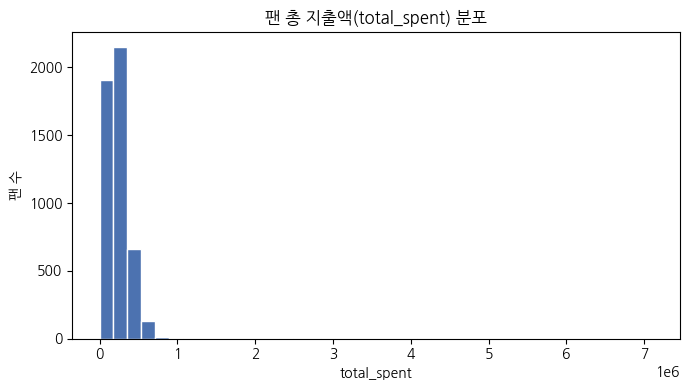

count    4.887000e+03
mean     2.445450e+05
std      2.644495e+05
min      0.000000e+00
25%      1.349855e+05
50%      2.128880e+05
75%      3.119365e+05
max      7.105233e+06
Name: total_spent, dtype: float64


In [13]:
# 총 지출액(total_spent)이 어떤 모양으로 분포되어 있는지 히스토그램으로 확인합니다.
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(clean["total_spent"], bins=40, color="#4C72B0", edgecolor="white")   # 40개 구간으로 나눠서 그리기
ax.set_title("팬 총 지출액(total_spent) 분포")
ax.set_xlabel("total_spent")
ax.set_ylabel("팬 수")
plt.tight_layout()   # 여백을 자동으로 조정해 라벨이 잘리지 않게 함
plt.savefig(f"{OUT_DIR}/eda_total_spent_hist.png", dpi=120)   # 이미지 파일로 저장 (나중에 README 등에서 재사용 가능)
plt.show()

# describe()로 평균, 중앙값, 최솟값/최댓값 등 기본 통계량도 함께 확인
print(clean["total_spent"].describe())

**해석**: 대부분의 팬은 총 지출액 20~30만원대에 몰려 있는 오른쪽 꼬리가 긴(right-skewed) 분포입니다.
평균(약 24만원)이 중앙값보다 높게 나오는 것도 소수의 고액 지출 팬(VIP 등급 등)이 평균을 끌어올리고
있음을 보여줍니다. 이 때문에 앞서 3번 정제 단계에서 상단 이상치를 제거하지 않고 유지한 판단이 뒷받침됩니다.


### 4-2. 범주별 비교 — 구단(`favorite_team`)별 평균 지출액

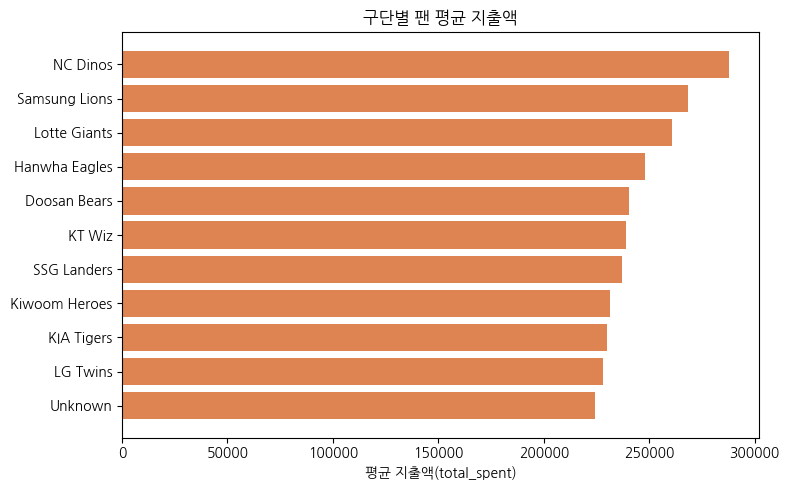

,favorite_team,fan_count,avg_total_spent,avg_attended_games,season_ticket_rate
0,NC Dinos,393,287656.1,10.8,0.5
1,Samsung Lions,486,268435.5,10.7,0.5
2,Lotte Giants,446,260546.8,10.8,0.5
3,Hanwha Eagles,313,248153.7,10.8,0.5
4,Doosan Bears,634,240504.8,10.9,0.5
5,KT Wiz,235,238980.3,11.0,0.5
6,SSG Landers,457,237191.3,11.2,0.5
7,Kiwoom Heroes,405,231355.7,10.9,0.5
8,KIA Tigers,634,229731.9,10.6,0.4
9,LG Twins,785,228183.9,10.6,0.5


In [14]:
# 구단(favorite_team)별로 그룹을 묶어서(groupby) 팬 수, 평균 지출액, 평균 관람 경기 수,
# 시즌권 보유율을 한 번에 집계합니다.
team_kpi = (
    clean.groupby("favorite_team")
    .agg(fan_count=("customer_id", "count"),             # 그룹별 행 개수 = 팬 수
         avg_total_spent=("total_spent", "mean"),         # 평균 지출액
         avg_attended_games=("attended_games", "mean"),   # 평균 관람 경기 수
         season_ticket_rate=("season_ticket_yn", "mean")) # 0/1의 평균 = 시즌권 보유 비율
    .round(1)
    .sort_values("avg_total_spent", ascending=False)   # 평균 지출액이 높은 순으로 정렬
    .reset_index()
)

# 평균 지출액을 구단별 가로 막대그래프로 시각화 (큰 값이 위로 오도록 invert_yaxis 사용)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(team_kpi["favorite_team"], team_kpi["avg_total_spent"], color="#DD8452")
ax.invert_yaxis()
ax.set_xlabel("평균 지출액(total_spent)")
ax.set_title("구단별 팬 평균 지출액")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/eda_team_avg_spent_bar.png", dpi=120)
plt.show()

team_kpi

**해석**: NC Dinos 팬의 평균 지출액이 가장 높고, 팬 수가 가장 많은 LG Twins는 평균 지출액이 오히려
하위권입니다. 즉 **팬 규모가 큰 구단이 반드시 팬 1인당 지출도 높은 것은 아니다**는 인사이트를 얻을 수
있습니다. 시즌권 보유율은 구단 간 큰 차이 없이 대체로 0.5 근처로 나타나, 이번 샘플에서는 구단 선호가
시즌권 보유 여부와는 뚜렷한 관계를 보이지 않습니다.


### 4-3. 시간 흐름 — 가입연도별 팬 유입 및 평균 지출액

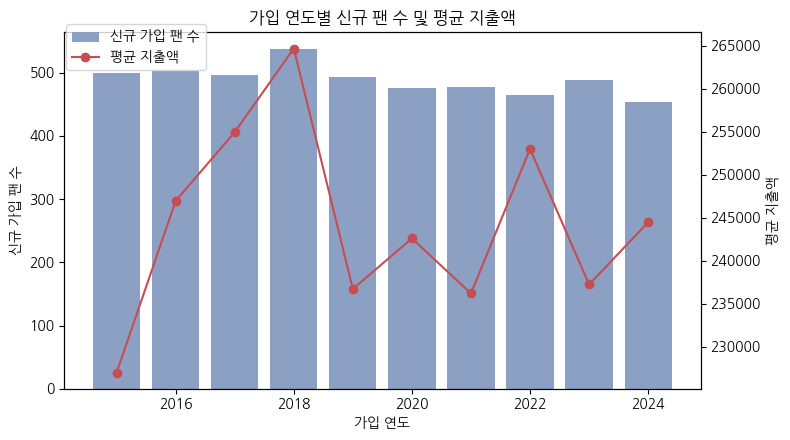

,new_fans,avg_total_spent
join_year,,
2015,499,226988.5
2016,502,246953.6
2017,497,254962.9
2018,537,264685.6
2019,493,236704.8
2020,475,242594.6
2021,477,236188.3
2022,465,253009.7
2023,488,237233.4


In [15]:
# join_date에서 연도만 뽑아 join_year 컬럼을 새로 만듭니다. (.dt.year는 datetime 컬럼에서 연도만 추출)
clean["join_year"] = clean["join_date"].dt.year

# 가입 연도별로 신규 팬 수와 평균 지출액을 함께 집계합니다.
year_trend = (
    clean.groupby("join_year")
    .agg(new_fans=("customer_id", "count"), avg_total_spent=("total_spent", "mean"))
    .round(1)
)

# 막대그래프(신규 팬 수)와 꺾은선그래프(평균 지출액)를 한 화면에 같이 그립니다.
# -> 두 지표의 단위(사람 수 vs 금액)가 달라서, twinx()로 오른쪽에 보조 y축을 하나 더 만듭니다.
fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.bar(year_trend.index, year_trend["new_fans"], color="#8CA0C4", label="신규 가입 팬 수")
ax1.set_xlabel("가입 연도")
ax1.set_ylabel("신규 가입 팬 수")

ax2 = ax1.twinx()   # x축은 공유하고 y축만 새로 만드는 보조 축
ax2.plot(year_trend.index, year_trend["avg_total_spent"], color="#C44E52", marker="o", label="평균 지출액")
ax2.set_ylabel("평균 지출액")

ax1.set_title("가입 연도별 신규 팬 수 및 평균 지출액")
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.95))   # 두 그래프의 범례를 한 번에 표시
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/eda_year_trend.png", dpi=120)
plt.show()

year_trend

**해석**: 가입 연도가 최근일수록 평균 지출액이 뚜렷하게 높아지거나 낮아지는 일관된 추세는 보이지
않습니다. 다만 연도별 신규 가입 팬 수는 특정 연도에 몰리는 구간이 있어, 이 데이터가 실제 마케팅
이벤트나 프로모션 시점과 연결되는지는 이 데이터만으로는 확인할 수 없습니다(6번 한계 참고).


### 4-4. 핵심 KPI 요약 — 멤버십 등급별

In [16]:
# 멤버십 등급(membership_tier)별로 팬 수, 평균 지출액, 평균 관람 경기 수를 집계합니다.
membership_kpi = (
    clean.groupby("membership_tier")
    .agg(fan_count=("customer_id", "count"),
         avg_total_spent=("total_spent", "mean"),
         avg_attended_games=("attended_games", "mean"))
    .round(1)
    .reset_index()
)
membership_kpi

,membership_tier,fan_count,avg_total_spent,avg_attended_games
0,Bronze,1863,249320.9,10.8
1,Gold,904,242506.0,10.7
2,Silver,1412,243592.4,10.8
3,Unknown,245,246106.3,10.9
4,VIP,463,231387.8,10.8


**해석(인사이트 요약)**

1. **구단별 팬 수와 팬 1인당 평균 지출액은 서로 다른 신호다.** LG Twins·KIA Tigers는 팬 수가 가장
   많지만 평균 지출은 하위권, NC Dinos는 팬 수는 중간이지만 평균 지출은 1위다. 마케팅 관점에서
   "팬이 많은 구단"과 "지출 여력이 큰 팬층을 가진 구단"을 구분해서 봐야 한다.
2. **멤버십 등급(Bronze~VIP)과 평균 지출액이 뚜렷한 정비례 관계를 보이지 않는다.** VIP 등급의 평균
   지출액이 Bronze/Silver보다 오히려 낮게 나타나, `membership_tier`가 순수 소비액 기준으로 매겨진
   등급이 아닐 가능성을 시사한다 (가입 기간, 프로모션 코드 등 다른 기준일 수 있음 — 후속 확인 필요).


## 5. 결과 저장

정제 데이터와 KPI 요약을 Parquet으로 저장하고, 같은 데이터를 CSV로도 저장해 용량을 비교합니다.

In [17]:
# 정제된 데이터와 KPI 요약표들을 Parquet 형식으로 저장합니다.
# index=False로 저장해서, 불필요한 인덱스 컬럼이 파일에 함께 저장되지 않도록 합니다.
clean.to_parquet(f"{OUT_DIR}/cleaned_data.parquet", index=False)

# 같은 데이터를 CSV로도 저장 — 오직 "용량 비교"만을 위한 임시 파일입니다.
clean.to_csv(f"{OUT_DIR}/cleaned_data_for_size_check.csv", index=False)

team_kpi.to_parquet(f"{OUT_DIR}/kpi_team_summary.parquet", index=False)
membership_kpi.to_parquet(f"{OUT_DIR}/kpi_membership_summary.parquet", index=False)
year_trend.reset_index().to_parquet(f"{OUT_DIR}/kpi_year_trend_summary.parquet", index=False)

# os.path.getsize()로 실제 파일 크기(바이트 단위)를 확인해 두 포맷을 비교합니다.
csv_size = os.path.getsize(f"{OUT_DIR}/cleaned_data_for_size_check.csv")
parquet_size = os.path.getsize(f"{OUT_DIR}/cleaned_data.parquet")
print(f"CSV 용량: {csv_size:,} bytes")
print(f"Parquet 용량: {parquet_size:,} bytes")
print(f"Parquet이 CSV의 약 {parquet_size/csv_size:.1%} 크기 (약 1/{csv_size/parquet_size:.1f})")

# 용량 비교가 끝났으니, 최종 산출물에는 필요 없는 임시 CSV 파일을 삭제합니다.
os.remove(f"{OUT_DIR}/cleaned_data_for_size_check.csv")

CSV 용량: 551,960 bytes
Parquet 용량: 140,488 bytes
Parquet이 CSV의 약 25.5% 크기 (약 1/3.9)


**한 줄 비교**: Parquet 파일이 CSV보다 훨씬 작고(용량 비교 결과는 위 출력 참고), 날짜 컬럼의
`datetime64[ns]` 자료형도 그대로 보존되어 다음 분석가가 다시 `pd.to_datetime()`을 호출할 필요가 없습니다.


## 6. 한계와 후속 질문

- **membership_tier 산정 기준을 알 수 없다.** EDA에서 등급과 평균 지출액이 정비례하지 않는 현상을
  발견했지만, 이 데이터만으로는 등급이 어떤 기준(가입 기간? 프로모션? 다른 채널?)으로 부여됐는지
  알 수 없어 원인을 단정할 수 없다. 등급 산정 로직 문서가 있다면 함께 봐야 한다.
- **가입 연도별 유입 추이의 원인을 설명할 변수가 없다.** 특정 연도에 신규 가입이 몰리는 패턴이
  보였지만, 프로모션·마케팅 캠페인·구단 성적 등 외부 요인 데이터가 없어 "왜" 몰렸는지는 추정만 가능하다.
- **동일 customer_id 스냅샷 충돌(25건)을 "최근 날짜 우선"으로만 해소했다.** 어떤 필드가 실제로
  바뀌었는지(지역 이전? 등급 변경?) 변경 이력 자체는 분석하지 않았다. 후속 분석에서는 필드별
  변경 내역을 diff로 추적해 볼 수 있다.
- **email 컬럼을 제거하여 유입 경로(referral_source)와 실제 채널 데이터를 연결하는 정밀 분석은
  하지 못했다.** 개인정보 보호가 우선이므로 이는 의도된 제약이다.
- 다음 분석에서는 구단 성적(순위·플레이오프 진출 여부)이나 시즌별 프로모션 정보를 추가로 확보하면,
  지출·유입 패턴의 원인을 더 설명력 있게 해석할 수 있을 것이다.
